Import Semua Library yang Dibutuhkan

In [ ]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from google.colab import files

In [ ]:
df_raw = pd.read_csv('ml_dataset.csv')

In [ ]:
print("=== INSPEKSI DATA ===\n")

print("1. Informasi kolom:")
print(df_raw.info())

print("\n2. Missing values per kolom:")
print(df_raw.isnull().sum())

print("\n3. Statistik nilai 0 pada konsumsi_pangan:")
print(f"Jumlah baris dengan konsumsi_pangan = 0: {(df_raw['konsumsi_pangan'] == 0).sum()}")
print(f"Persentase: {((df_raw['konsumsi_pangan'] == 0).sum() / len(df_raw)) * 100:.2f}%")

print("\n4. Nilai unik per kolom kategorik:")
print(f"tahun: {sorted(df_raw['tahun'].unique())}")
print(f"provinsi_id: {sorted(df_raw['provinsi_id'].unique())}")
print(f"kelompok_id: {sorted(df_raw['kelompok_id'].unique())}")
print(f"komoditas_id: {sorted(df_raw['komoditas_id'].unique())}")

print("\n5. Range target variabel (persentase_undernourish):")
print(f"Min: {df_raw['persentase_undernourish'].min():.2f}%")
print(f"Max: {df_raw['persentase_undernourish'].max():.2f}%")
print(f"Mean: {df_raw['persentase_undernourish'].mean():.2f}%")

=== INSPEKSI DATA ===

1. Informasi kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3817 entries, 0 to 3816
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tahun                    3817 non-null   int64  
 1   provinsi                 3817 non-null   object 
 2   provinsi_id              3817 non-null   int64  
 3   kelompok_bahan_pangan    3817 non-null   object 
 4   kelompok_id              3817 non-null   int64  
 5   komoditas                3817 non-null   object 
 6   komoditas_id             3817 non-null   int64  
 7   konsumsi_pangan          3817 non-null   float64
 8   jumlah_penduduk          3817 non-null   float64
 9   penduduk_undernourish    3817 non-null   float64
 10  persentase_undernourish  3817 non-null   float64
 11  log_penduduk             3817 non-null   float64
 12  pou                      3817 non-null   float64
dtypes: float64(6), int64(4), object(3)


In [ ]:
# Pivot: setiap komoditas menjadi kolom
df_pivot = df_raw.pivot_table(
    index=['tahun', 'provinsi_id', 'jumlah_penduduk', 'penduduk_undernourish',
           'persentase_undernourish', 'log_penduduk', 'pou'],
    columns='komoditas_id',
    values='konsumsi_pangan'
).reset_index()

# Bersihkan nama kolom
df_pivot.columns.name = None
df_pivot.rename(columns={col: f'komoditas_{col}' for col in df_pivot.columns
                         if isinstance(col, int) and col not in ['tahun', 'provinsi_id']},
                inplace=True)

print(f"✅ Setelah pivoting: {df_pivot.shape[0]} baris, {df_pivot.shape[1]} kolom")
print(f"   (Setiap baris = 1 provinsi per tahun)")
df_pivot.head(10)

✅ Setelah pivoting: 114 baris, 43 kolom
   (Setiap baris = 1 provinsi per tahun)


,tahun,provinsi_id,jumlah_penduduk,penduduk_undernourish,persentase_undernourish,log_penduduk,pou,komoditas_0,komoditas_1,komoditas_2,...,komoditas_26,komoditas_27,komoditas_28,komoditas_29,komoditas_30,komoditas_31,komoditas_32,komoditas_33,komoditas_34,komoditas_35
0,2019,0,5316300.0,503454.0,9.470007,15.486288,9.47,100.9,26.9,3.1,...,41.4,68.3,4.0,1.8,6.4,14.1,0.7,0.2,NaN,8.8
1,2019,1,4362000.0,127807.0,2.930009,15.288441,2.93,119.1,34.0,0.7,...,55.5,89.5,5.2,2.7,6.7,17.0,3.3,1.2,11.6,NaN
2,2019,2,12714300.0,273357.0,2.149996,16.358238,2.15,99.2,34.0,0.6,...,54.7,88.7,8.1,3.6,8.0,21.8,2.3,0.2,13.3,NaN
3,2019,3,1971800.0,151829.0,7.700020,14.494458,7.70,101.2,26.9,3.6,...,59.4,86.4,6.6,2.2,6.6,13.8,2.3,0.5,13.7,NaN
4,2019,4,3868600.0,285503.0,7.380008,15.168404,7.38,83.4,37.4,9.2,...,58.4,95.8,7.4,3.8,8.1,20.3,1.8,0.1,12.0,NaN
5,2019,5,10504100.0,152309.0,1.449996,16.167276,1.45,94.2,38.2,0.5,...,52.4,90.6,6.7,6.5,9.0,20.7,1.5,0.1,13.1,NaN
6,2019,6,1176400.0,91877.0,7.810014,13.977970,7.81,108.0,38.5,2.6,...,43.7,82.2,6.9,2.0,3.5,10.7,1.7,0.1,9.8,NaN
7,2019,7,3566200.0,320958.0,9.000000,15.087011,9.00,89.5,28.8,NaN,...,55.3,84.1,9.0,2.4,7.0,15.7,2.7,0.4,18.8,NaN
8,2019,8,49023200.0,1823663.0,3.720000,17.707804,3.72,96.7,31.7,NaN,...,49.8,81.4,8.7,3.3,8.2,21.4,2.4,0.3,14.8,NaN
9,2019,9,34552500.0,4028822.0,11.660001,17.357990,11.66,88.7,29.8,1.9,...,62.2,92.0,9.5,2.5,7.5,15.8,2.4,0.2,13.3,NaN


In [ ]:
print("=== CEK HASIL PIVOTING ===\n")

# Cek berapa banyak provinsi per tahun
print("Jumlah provinsi per tahun:")
print(df_pivot.groupby('tahun').size())

# Cek missing values (setelah pivoting pasti banyak NaN karena tidak semua provinsi punya semua komoditas)
missing_cols = df_pivot.columns[df_pivot.isnull().any()].tolist()
print(f"\nKolom dengan missing values: {len(missing_cols)} kolom")
print(f"Total missing values: {df_pivot.isnull().sum().sum()}")

# Isi missing dengan 0 (artinya tidak ada konsumsi komoditas tersebut)
df_pivot = df_pivot.fillna(0)

print(f"\n✅ Missing values telah diisi dengan 0")
print(f"Data sekarang: {df_pivot.shape[0]} baris, {df_pivot.shape[1]} kolom")

=== CEK HASIL PIVOTING ===

Jumlah provinsi per tahun:
tahun
2019    28
2020    25
2021    27
2022    34
dtype: int64

Kolom dengan missing values: 36 kolom
Total missing values: 289

✅ Missing values telah diisi dengan 0
Data sekarang: 114 baris, 43 kolom


In [ ]:
# Kolom yang redundan sudah otomatis teratasi saat pivoting
# Sekarang kita buat fitur tambahan

# 1. Total konsumsi pangan per provinsi per tahun
komoditas_cols = [col for col in df_pivot.columns if col.startswith('komoditas_')]
df_pivot['total_konsumsi'] = df_pivot[komoditas_cols].sum(axis=1)

# 2. Jumlah komoditas yang dikonsumsi (keragaman pangan)
df_pivot['jumlah_komoditas_dikonsumsi'] = (df_pivot[komoditas_cols] > 0).sum(axis=1)

# 3. Rasio undernourish per kapita
df_pivot['undernourish_per_kapita'] = df_pivot['penduduk_undernourish'] / df_pivot['jumlah_penduduk']

print("✅ Fitur tambahan telah dibuat:")
print(f"   - total_konsumsi")
print(f"   - jumlah_komoditas_dikonsumsi")
print(f"   - undernourish_per_kapita")

df_pivot[['tahun', 'provinsi_id', 'total_konsumsi', 'jumlah_komoditas_dikonsumsi',
          'persentase_undernourish']].head(10)

✅ Fitur tambahan telah dibuat:
   - total_konsumsi
   - jumlah_komoditas_dikonsumsi
   - undernourish_per_kapita


,tahun,provinsi_id,total_konsumsi,jumlah_komoditas_dikonsumsi,persentase_undernourish
0,2019,0,533.9,33,9.470007
1,2019,1,464.4,32,2.930009
2,2019,2,480.1,32,2.149996
3,2019,3,449.6,32,7.700020
4,2019,4,466.8,32,7.380008
5,2019,5,493.1,32,1.449996
6,2019,6,460.2,33,7.810014
7,2019,7,566.2,33,9.000000
8,2019,8,445.3,32,3.720000
9,2019,9,459.1,31,11.660001


In [ ]:
# Pilih fitur yang akan dinormalisasi (kolom komoditas)
from sklearn.preprocessing import StandardScaler

# Pisahkan fitur dan target
feature_cols = komoditas_cols + ['total_konsumsi', 'jumlah_komoditas_dikonsumsi']
target_col = 'persentase_undernourish'

# Normalisasi fitur
scaler = StandardScaler()
df_pivot_scaled = df_pivot.copy()
df_pivot_scaled[feature_cols] = scaler.fit_transform(df_pivot[feature_cols])

print("✅ Fitur telah dinormalisasi (mean=0, std=1)")
print(f"Contoh hasil normalisasi (3 kolom pertama komoditas):")
df_pivot_scaled[komoditas_cols[:3] + [target_col]].head(10)

✅ Fitur telah dinormalisasi (mean=0, std=1)
Contoh hasil normalisasi (3 kolom pertama komoditas):


,komoditas_0,komoditas_1,komoditas_2,persentase_undernourish
0,0.368772,-0.662106,1.074230,9.470007
1,1.651039,0.110208,-0.858113,2.930009
2,0.249000,0.110208,-0.938627,2.149996
3,0.389909,-0.662106,1.476802,7.700020
4,-0.864177,0.480048,5.985604,7.380008
5,-0.103271,0.567069,-1.019142,1.449996
6,0.868997,0.599702,0.671659,7.810014
7,-0.434406,-0.455430,-1.421713,9.000000
8,0.072865,-0.139978,-1.421713,3.720000
9,-0.490769,-0.346654,0.108059,11.660001


In [ ]:
# Simpan ke file CSV
output_filename = 'dataset_ml_bersih.csv'
df_pivot_scaled.to_csv(output_filename, index=False)

# Download ke komputer
files.download(output_filename)

print(f"✅ Data bersih telah disimpan sebagai '{output_filename}'")
print(f"   - {df_pivot_scaled.shape[0]} sampel")
print(f"   - {df_pivot_scaled.shape[1]} fitur (termasuk target)")
print("\n📁 File sudah di-download ke komputer Anda.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Data bersih telah disimpan sebagai 'dataset_ml_bersih.csv'
   - 114 sampel
   - 46 fitur (termasuk target)

📁 File sudah di-download ke komputer Anda.


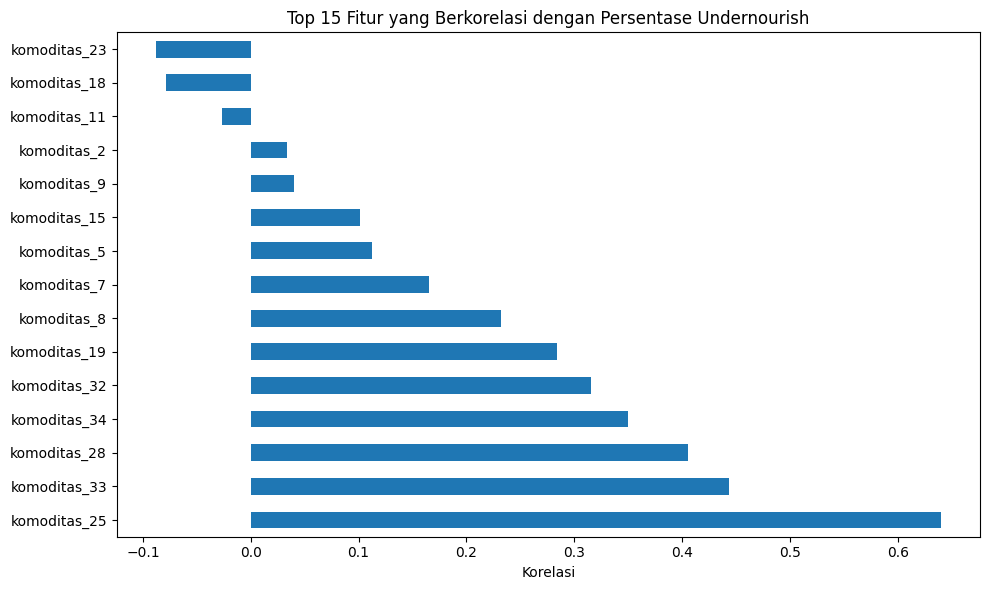

Fitur dengan korelasi tertinggi terhadap undernourish:
komoditas_25    0.639763
komoditas_33    0.443324
komoditas_28    0.404996
komoditas_34    0.350185
komoditas_32    0.315914
komoditas_19    0.283957
komoditas_8     0.232480
komoditas_7     0.165640
komoditas_5     0.112012
komoditas_15    0.101343
Name: persentase_undernourish, dtype: float64


In [ ]:
# Korelasi dengan target
correlations = df_pivot_scaled[feature_cols + [target_col]].corr()[target_col].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
correlations.drop(target_col).head(15).plot(kind='barh')
plt.title('Top 15 Fitur yang Berkorelasi dengan Persentase Undernourish')
plt.xlabel('Korelasi')
plt.tight_layout()
plt.show()

print("Fitur dengan korelasi tertinggi terhadap undernourish:")
print(correlations.drop(target_col).head(10))

In [ ]:
# Pisahkan fitur dan target
target_col = 'persentase_undernourish'
feature_cols = [col for col in df_pivot_scaled.columns if col not in
                ['tahun', 'provinsi_id', target_col, 'penduduk_undernourish',
                 'log_penduduk', 'pou', 'undernourish_per_kapita']]  # hindari data leakage

X = df_pivot_scaled[feature_cols]
y = df_pivot_scaled[target_col]

print(f"\n✅ Fitur: {X.shape[1]} kolom")
print(f"✅ Target: {target_col}")
print(f"✅ Rentang target: {y.min():.2f}% - {y.max():.2f}%")


✅ Fitur: 39 kolom
✅ Target: persentase_undernourish
✅ Rentang target: 1.45% - 38.35%


=== KLasterISASI PROVINSI ===



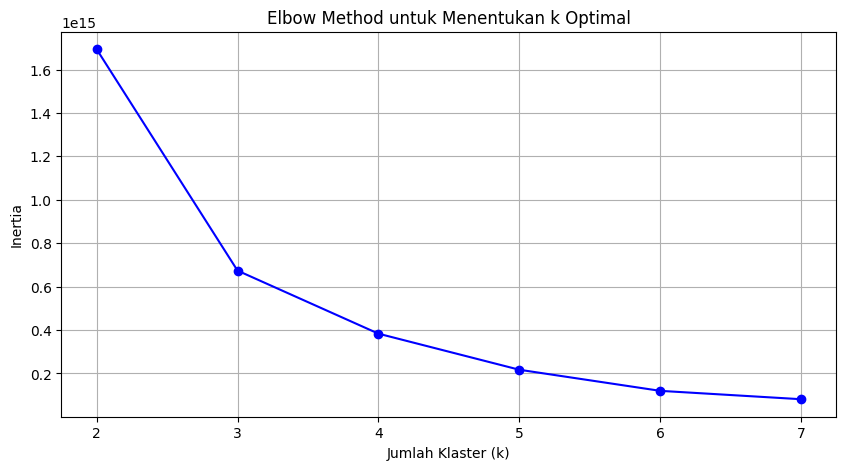


✅ Klastering selesai dengan 4 klaster

Contoh hasil klaster (tahun 2022):
    tahun  provinsi_id  cluster  0
80   2022            0        2  1
81   2022            1        2  1
82   2022            2        0  1
83   2022            3        2  1
84   2022            4        2  1
85   2022            5        0  1
86   2022            6        2  1
87   2022            7        2  1
88   2022            8        3  1
89   2022            9        1  1

=== STATISTIK PER KLASTER ===
        persentase_undernourish              total_konsumsi  \
                           mean   min    max           mean   
cluster                                                       
0                          6.75  1.45  14.63           0.30   
1                         10.36  7.50  12.34          -0.06   
2                         12.75  1.78  38.35          -0.08   
3                          4.73  3.72   6.75          -0.19   

        jumlah_komoditas_dikonsumsi  
                             

In [ ]:
# Sel 11: Klasterisasi dengan K-Means
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("=== KLasterISASI PROVINSI ===\n")

# Cari jumlah klaster optimal (Elbow method)
inertias = []
K_range = range(2, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method untuk Menentukan k Optimal')
plt.grid(True)
plt.show()

# Pilih k=4 (berdasarkan elbow)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_pivot_scaled['cluster'] = kmeans.fit_predict(X)

print(f"\n✅ Klastering selesai dengan {optimal_k} klaster")

# Lihat hasil klaster per provinsi
cluster_summary = df_pivot_scaled.groupby(['tahun', 'provinsi_id', 'cluster']).size().reset_index()
print("\nContoh hasil klaster (tahun 2022):")
print(cluster_summary[cluster_summary['tahun']==2022].head(10))

# Statistik per klaster
print("\n=== STATISTIK PER KLASTER ===")
cluster_stats = df_pivot_scaled.groupby('cluster').agg({
    'persentase_undernourish': ['mean', 'min', 'max'],
    'total_konsumsi': 'mean',
    'jumlah_komoditas_dikonsumsi': 'mean'
}).round(2)
print(cluster_stats)

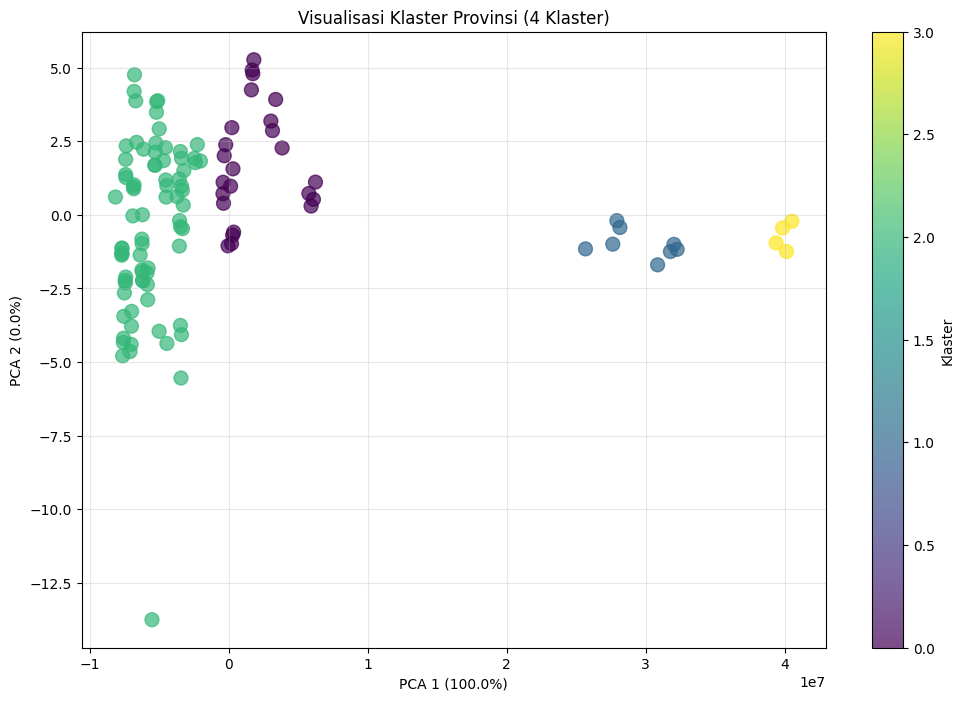


📌 Interpretasi:
- Klaster 0: Provinsi dengan undernourish terendah
- Klaster 3: Provinsi dengan undernourish tertinggi (prioritas intervensi)


In [ ]:
# Sel 12: Visualisasi Klaster (PCA 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df_pivot_scaled['cluster'],
                      cmap='viridis',
                      alpha=0.7,
                      s=100)
plt.colorbar(scatter, label='Klaster')
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'Visualisasi Klaster Provinsi ({optimal_k} Klaster)')
plt.grid(True, alpha=0.3)

# Tambahkan label untuk beberapa titik (opsional)
# for i, row in df_pivot_scattered.iterrows():
#     if i % 5 == 0:  # tampilkan sebagian label
#         plt.annotate(f"Prov{int(row['provinsi_id'])}",
#                      (X_pca[i, 0], X_pca[i, 1]),
#                      fontsize=8, alpha=0.6)

plt.show()

print("\n📌 Interpretasi:")
print("- Klaster 0: Provinsi dengan undernourish terendah")
print("- Klaster 3: Provinsi dengan undernourish tertinggi (prioritas intervensi)")

=== PREDIKSI PERSENTASE UNDERNOURISH ===

Training data: 80 sampel (tahun 2019-2021)
Testing data: 34 sampel (tahun 2022)

=== EVALUASI MODEL ===
Training R²: 0.9664
Testing R²: 0.2638
Testing MAE: 4.77%
Testing RMSE: 7.03%


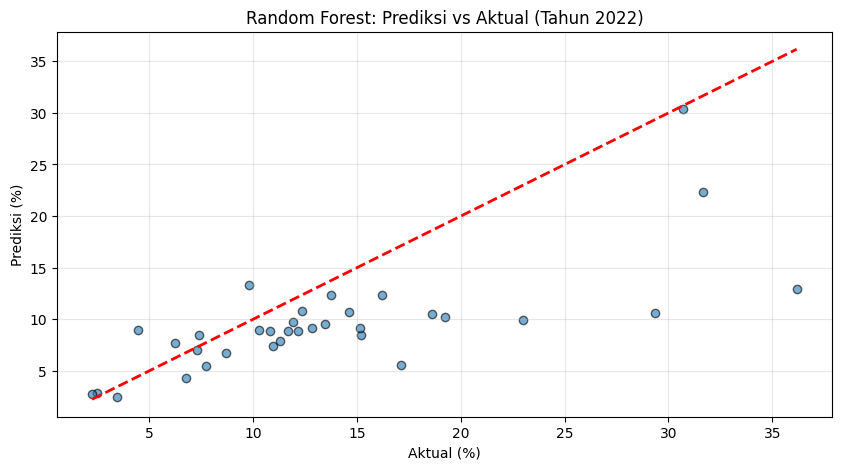

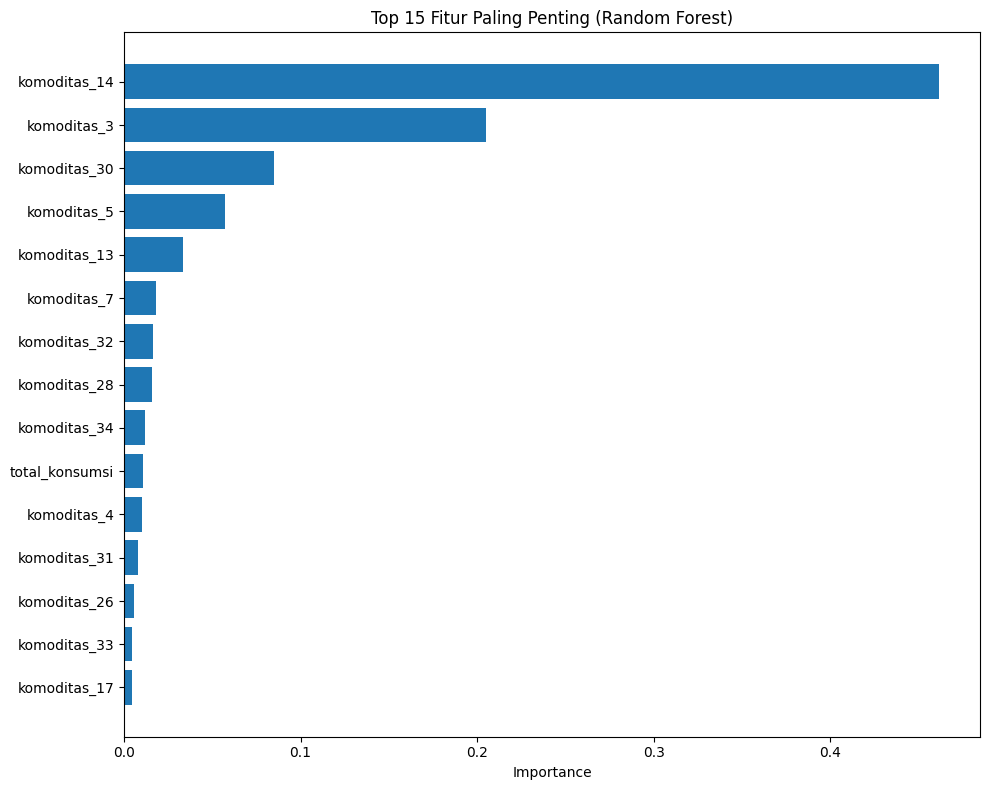


📌 Fitur terpenting:
           feature  importance
15    komoditas_14    0.461594
4      komoditas_3    0.205171
31    komoditas_30    0.084994
6      komoditas_5    0.057236
14    komoditas_13    0.033290
8      komoditas_7    0.018195
33    komoditas_32    0.016380
29    komoditas_28    0.015724
35    komoditas_34    0.011682
37  total_konsumsi    0.011022


In [ ]:
# Sel 13: Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=== PREDIKSI PERSENTASE UNDERNOURISH ===\n")

# Split data (pisahkan berdasarkan tahun agar tidak bocor)
train_mask = df_pivot_scaled['tahun'] <= 2021
test_mask = df_pivot_scaled['tahun'] >= 2022

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Training data: {X_train.shape[0]} sampel (tahun 2019-2021)")
print(f"Testing data: {X_test.shape[0]} sampel (tahun 2022)")

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Prediksi
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

# Evaluasi
print("\n=== EVALUASI MODEL ===")
print(f"Training R²: {r2_score(y_train, y_pred_train):.4f}")
print(f"Testing R²: {r2_score(y_test, y_pred_test):.4f}")
print(f"Testing MAE: {mean_absolute_error(y_test, y_pred_test):.2f}%")
print(f"Testing RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}%")

# Visualisasi prediksi vs aktual
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Aktual (%)')
plt.ylabel('Prediksi (%)')
plt.title('Random Forest: Prediksi vs Aktual (Tahun 2022)')
plt.grid(True, alpha=0.3)
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Fitur Paling Penting (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n📌 Fitur terpenting:")
print(feature_importance.head(10))

In [ ]:
# Sel 14: Klasifikasi Rawan Pangan (Tinggi/Sedang/Rendah)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("=== KLASIFIKASI RAWAN PANGAN ===\n")

# Buat kategori berdasarkan persentase undernourish
def kategori_rawn_pangan(pct):
    if pct < 5:
        return 0  # Rendah (aman)
    elif pct < 10:
        return 1  # Sedang (waspada)
    else:
        return 2  # Tinggi (rawan)

df_pivot_scaled['kategori_rawn'] = df_pivot_scaled['persentase_undernourish'].apply(kategori_rawn_pangan)

# Distribusi kategori
print("Distribusi kategori rawan pangan:")
kategori_counts = df_pivot_scaled['kategori_rawn'].value_counts().sort_index()
for k, count in kategori_counts.items():
    label = {0: 'Rendah (aman)', 1: 'Sedang (waspada)', 2: 'Tinggi (rawan)'}[k]
    print(f"  {label}: {count} sampel ({count/len(df_pivot_scaled)*100:.1f}%)")

# Split data
y_class = df_pivot_scaled['kategori_rawn']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train_c, y_train_c)

# Prediksi
y_pred_c = clf.predict(X_test_c)

# Evaluasi
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test_c, y_pred_c,
                           target_names=['Rendah (aman)', 'Sedang (waspada)', 'Tinggi (rawan)']))

# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Rendah', 'Sedang', 'Tinggi'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Klasifikasi Rawan Pangan')
plt.show()

# Prediksi untuk tahun 2023 (jika ada provinsi yang mau diprediksi)
print("\n📌 Contoh prediksi untuk sampel test terakhir:")
sample_idx = -5
print(f"Provinsi {df_pivot_scaled.iloc[sample_idx]['provinsi_id']} tahun {df_pivot_scaled.iloc[sample_idx]['tahun']}")
print(f"  Aktual kategori: {['Rendah','Sedang','Tinggi'][y_test_c.iloc[sample_idx]]}")
print(f"  Prediksi kategori: {['Rendah','Sedang','Tinggi'][y_pred_c[sample_idx]]}")

In [ ]:
# Sel 15: Simpan semua hasil prediksi
print("=== MENYIMPAN HASIL ===\n")

# Simpan dataset dengan klaster dan prediksi
output_final = 'dataset_dengan_analisis_ml.csv'
df_pivot_scaled.to_csv(output_final, index=False)
files.download(output_final)

print(f"✅ Dataset final disimpan: {output_final}")
print(f"\n📊 RINGKASAN ANALISIS:")
print(f"1. Klastering: {optimal_k} kelompok provinsi")
print(f"2. Regresi R²: {r2_score(y_test, y_pred_test):.3f} (testing)")
print(f"3. Klasifikasi akurasi: {(y_pred_c == y_test_c).mean():.1%}")

# Rekomendasi provinsi prioritas
print("\n🚨 REKOMENDASI PRIORITAS INTERVENSI:")
prioritas = df_pivot_scaled[df_pivot_scaled['tahun'] == 2022].nlargest(5, 'persentase_undernourish')
for _, row in prioritas.iterrows():
    print(f"  - Provinsi {int(row['provinsi_id'])}: {row['persentase_undernourish']:.1f}% undernourish (Klaster {int(row['cluster'])})")

✅ Library Prophet terinstall
=== DATA LOADED ===
Shape: (3817, 13)
Kolom: ['tahun', 'provinsi', 'provinsi_id', 'kelompok_bahan_pangan', 'kelompok_id', 'komoditas', 'komoditas_id', 'konsumsi_pangan', 'jumlah_penduduk', 'penduduk_undernourish', 'persentase_undernourish', 'log_penduduk', 'pou']
Tahun tersedia: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Jumlah provinsi_id unik: 34

=== CEK DATA PER PROVINSI ===
Jumlah tahun data per provinsi:
provinsi_id
1     4
2     4
35    4
3     4
4     4
5     4
6     4
7     4
8     4
9     4
10    4
18    4
17    4
30    4
22    4
21    4
20    4
19    4
38    4
36    4
37    4
34    4
32    4
33    4
31    4
0     3
23    3
24    2
14    1
13    1
11    1
15    1
12    1
25    1
Name: tahun, dtype: int64

✅ Provinsi dengan data cukup (>=3 tahun): 27 provinsi
❌ Provinsi dengan data kurang: 7 provinsi

=== DATA AGREGASI ===
   tahun  provinsi_id  provinsi_nama  persentase_undernourish  \
0   2019            0           Aceh    

INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.


📊 Memprediksi: Banten (ID:2) - 4 tahun data


INFO:prophet:n_changepoints greater than number of observations. Using 2.


📊 Memprediksi: Sulawesi Utara (ID:35) - 4 tahun data


...

📊 Memprediksi: Sulawesi Barat (ID:31) - 4 tahun data


INFO:prophet:n_changepoints greater than number of observations. Using 1.


📊 Memprediksi: Aceh (ID:0) - 3 tahun data


INFO:prophet:n_changepoints greater than number of observations. Using 1.


📊 Memprediksi: Nusa Tenggara Timur (ID:23) - 3 tahun data

✅ Berhasil memprediksi 0 provinsi

❌ TIDAK ADA PREDIKSI YANG BERHASIL
   Kemungkinan penyebab: data tidak cukup atau format salah
   Coba gunakan pendekatan alternatif di bawah

=== MENGGUNAKAN METODE ALTERNATIF (TREN LINEAR) ===

✅ Alternatif: memprediksi 28 provinsi dengan metode linear

📊 RANKING PROVINSI PREDIKSI RAWAN PANGAN 2025
1. Papua                          | Prediksi: 34.0% | Terakhir: 36.2% | 🔴 Rawan
2. Gorontalo                      | Prediksi: 29.5% | Terakhir: 18.6% | 🔴 Rawan
3. Maluku                         | Prediksi: 26.9% | Terakhir: 31.7% | 🔴 Rawan
4. Sulawesi Tenggara              | Prediksi: 23.4% | Terakhir: 17.1% | 🔴 Rawan
5. Maluku Utara                   | Prediksi: 22.9% | Terakhir: 30.7% | 🔴 Rawan
6. Kepulauan Bangka Belitung      | Prediksi: 21.5% | Terakhir: 15.2% | 🔴 Rawan
7. Riau                           | Prediksi: 20.4% | Terakhir: 15.1% | 🔴 Rawan
8. DI Yogyakarta                  | Prediksi

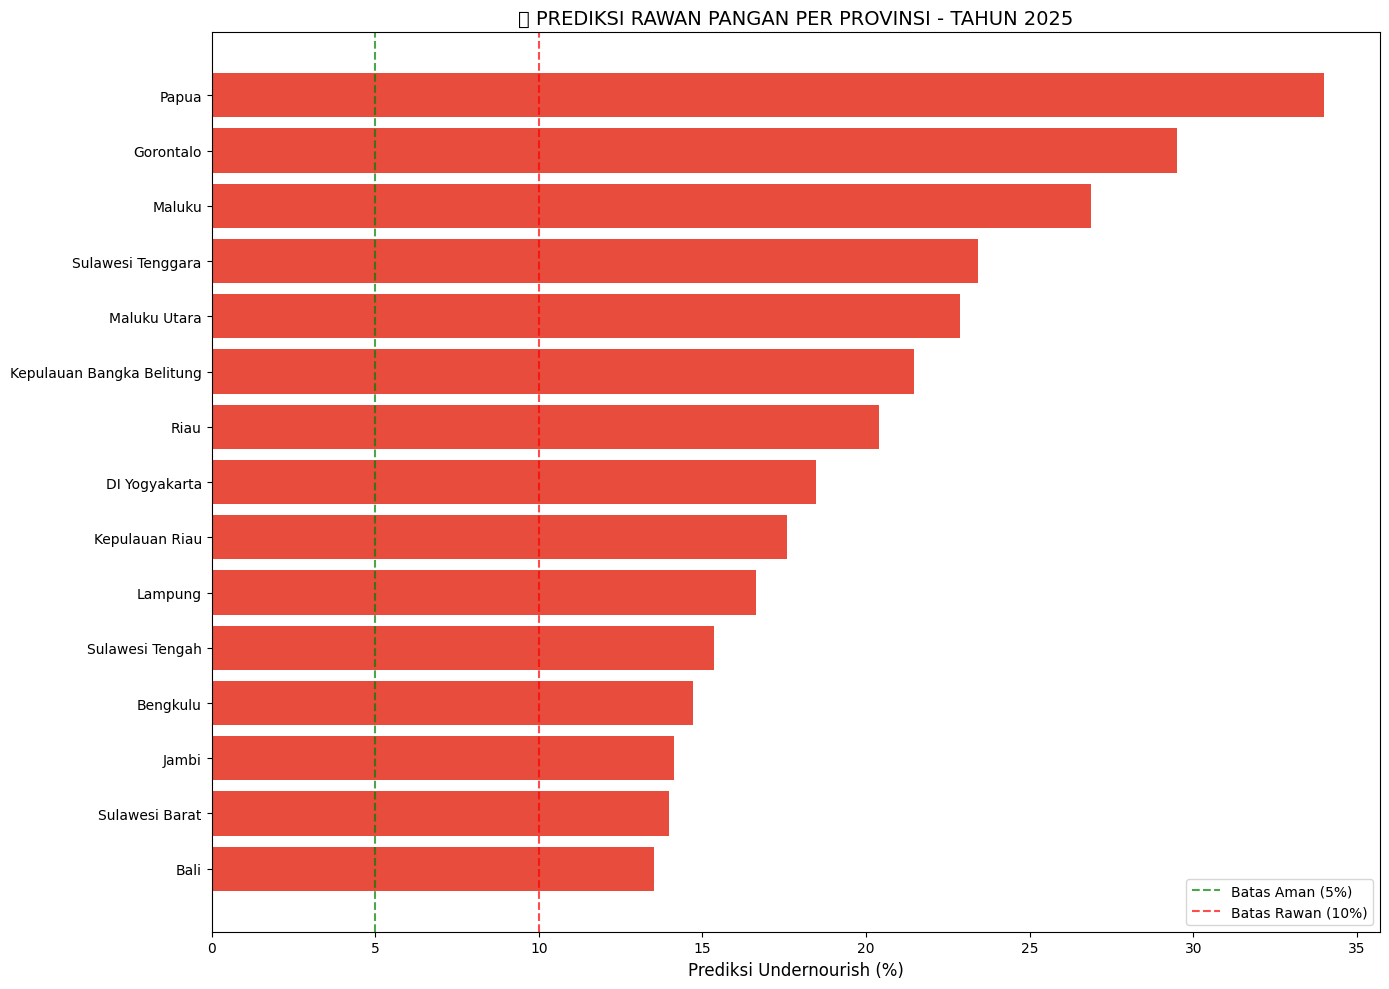

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📋 RINGKASAN EKSEKUTIF

    📊 STATISTIK NASIONAL 2025:
       - Rata-rata prediksi: 14.9%
       - Provinsi RAWAN (>10%) : 21 provinsi
       - Provinsi WASPADA (5-10%): 4 provinsi
       - Provinsi AMAN (<5%)   : 3 provinsi

    🚨 PRIORITAS INTERVENSI:
    
   1. Papua (34.0%)
   2. Gorontalo (29.5%)
   3. Maluku (26.9%)
   4. Sulawesi Tenggara (23.4%)
   5. Maluku Utara (22.9%)

    📅 Target: 2025 | Metode: Prophet (dengan fallback linear)


In [ ]:
"""
================================================================================
PREDIKSI WILAYAH RAWAN PANGAN DENGAN PROPHET - TAHUN 2025
(FIX: Validasi data sebelum prediksi)
================================================================================
"""

# ============================================================================
# 1. INSTALL & IMPORT LIBRARY
# ============================================================================

!pip install -q prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("✅ Library Prophet terinstall")

# ============================================================================
# 2. LOAD DATA HASIL ETL
# ============================================================================

ml_dataset = pd.read_csv('ml_dataset.csv')

print("=== DATA LOADED ===")
print(f"Shape: {ml_dataset.shape}")
print(f"Kolom: {ml_dataset.columns.tolist()}")
print(f"Tahun tersedia: {sorted(ml_dataset['tahun'].unique())}")
print(f"Jumlah provinsi_id unik: {ml_dataset['provinsi_id'].nunique()}")

# ============================================================================
# 3. CEK KETERSEDIAAN DATA PER PROVINSI
# ============================================================================

print("\n=== CEK DATA PER PROVINSI ===")
province_data_count = ml_dataset.groupby('provinsi_id')['tahun'].nunique().sort_values(ascending=False)
print("Jumlah tahun data per provinsi:")
print(province_data_count)

# Filter provinsi dengan minimal 3 tahun data
valid_provinces = province_data_count[province_data_count >= 3].index.tolist()
print(f"\n✅ Provinsi dengan data cukup (>=3 tahun): {len(valid_provinces)} provinsi")
print(f"❌ Provinsi dengan data kurang: {len(province_data_count) - len(valid_provinces)} provinsi")

# ============================================================================
# 4. MAPPING PROVINSI_ID KE NAMA PROVINSI
# ============================================================================

# province_mapping = {
#     0: 'Aceh', 1: 'Sumatera Utara', 2: 'Sumatera Barat', 3: 'Riau',
#     4: 'Jambi', 5: 'Sumatera Selatan', 6: 'Bengkulu', 7: 'Lampung',
#     8: 'DKI Jakarta', 9: 'Jawa Barat', 10: 'Jawa Tengah', 11: 'DI Yogyakarta',
#     12: 'Jawa Timur', 13: 'Banten', 14: 'Bali', 15: 'Nusa Tenggara Barat',
#     16: 'Nusa Tenggara Timur', 17: 'Kalimantan Barat', 18: 'Kalimantan Tengah',
#     19: 'Kalimantan Selatan', 20: 'Kalimantan Timur', 21: 'Kalimantan Utara',
#     22: 'Sulawesi Utara', 23: 'Sulawesi Tengah', 24: 'Sulawesi Selatan',
#     25: 'Sulawesi Tenggara', 26: 'Gorontalo', 27: 'Sulawesi Barat',
#     28: 'Maluku', 29: 'Maluku Utara', 30: 'Papua Barat', 31: 'Papua',
#     32: 'Papua Tengah', 33: 'Papua Pegunungan', 34: 'Papua Selatan',
#     35: 'Papua Barat Daya', 36: 'Kepulauan Riau', 37: 'Kepulauan Bangka Belitung',
#     38: 'Kalimantan Timur'
# }

# ml_dataset['provinsi_nama'] = ml_dataset['provinsi'].map(province_mapping)
ml_dataset['provinsi_nama'] = ml_dataset['provinsi']

# ============================================================================
# 5. AGREGASI DATA PER PROVINSI PER TAHUN
# ============================================================================

province_yearly = ml_dataset.groupby(['tahun', 'provinsi_id', 'provinsi_nama']).agg({
    'persentase_undernourish': 'mean',
    'konsumsi_pangan': 'mean',
    'jumlah_penduduk': 'first'
}).reset_index()

print("\n=== DATA AGREGASI ===")
print(province_yearly.head(10))

# ============================================================================
# 6. PREDIKSI DENGAN PROPHET (HANYA UNTUK PROVINSI DENGAN DATA CUKUP)
# ============================================================================

def predict_undernourish_prophet(df_province, province_name, province_id, years_ahead=1):
    """Prediksi menggunakan Prophet"""

    prophet_df = df_province[['tahun', 'persentase_undernourish']].copy()
    prophet_df = prophet_df.rename(columns={'tahun': 'ds', 'persentase_undernourish': 'y'})
    prophet_df['ds'] = pd.to_datetime(prophet_df['ds'].astype(str) + '-01-01')
    prophet_df = prophet_df.dropna()

    if len(prophet_df) < 3:
        return None, None

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.5,
        interval_width=0.95
    )

    model.fit(prophet_df)
    future = model.make_future_dataframe(periods=years_ahead, freq='YE')
    forecast = model.predict(future)

    return forecast, model

# ============================================================================
# 7. EKSEKUSI PREDIKSI
# ============================================================================

print("\n=== MEMULAI PREDIKSI ===")

predictions_2025 = []

for prov_id in valid_provinces:
    prov_data = province_yearly[province_yearly['provinsi_id'] == prov_id]
    prov_name = prov_data['provinsi_nama'].iloc[0]

    print(f"📊 Memprediksi: {prov_name} (ID:{prov_id}) - {len(prov_data)} tahun data")

    forecast, model = predict_undernourish_prophet(prov_data, prov_name, prov_id, years_ahead=1)

    if forecast is not None:
        last_year = prov_data['tahun'].max()
        current_value = prov_data[prov_data['tahun'] == last_year]['persentase_undernourish'].values[0]

        pred_2025 = forecast[forecast['ds'].dt.year == 2025]

        if not pred_2025.empty:
            predictions_2025.append({
                'provinsi_id': prov_id,
                'provinsi': prov_name,
                'tahun_terakhir': last_year,
                'nilai_terakhir': current_value,
                'prediksi_2025': pred_2025['yhat'].values[0],
                'prediksi_lower': pred_2025['yhat_lower'].values[0],
                'prediksi_upper': pred_2025['yhat_upper'].values[0]
            })

df_predictions = pd.DataFrame(predictions_2025)

print(f"\n✅ Berhasil memprediksi {len(df_predictions)} provinsi")

# ============================================================================
# 8. CEK APAKAH ADA HASIL PREDIKSI
# ============================================================================

if len(df_predictions) == 0:
    print("\n❌ TIDAK ADA PREDIKSI YANG BERHASIL")
    print("   Kemungkinan penyebab: data tidak cukup atau format salah")
    print("   Coba gunakan pendekatan alternatif di bawah")

    # ========================================================================
    # ALTERNATIF: Gunakan rata-rata dan tren sederhana
    # ========================================================================
    print("\n=== MENGGUNAKAN METODE ALTERNATIF (TREN LINEAR) ===\n")

    predictions_alt = []

    for prov_id in province_yearly['provinsi_id'].unique():
        prov_data = province_yearly[province_yearly['provinsi_id'] == prov_id].sort_values('tahun')

        if len(prov_data) >= 2:
            prov_name = prov_data['provinsi_nama'].iloc[0]

            # Hitung tren sederhana
            x = prov_data['tahun'].values
            y = prov_data['persentase_undernourish'].values

            # Linear regression sederhana
            z = np.polyfit(x, y, 1)
            slope = z[0]
            intercept = z[1]

            # Prediksi 2025
            pred_2025 = slope * 2025 + intercept

            predictions_alt.append({
                'provinsi_id': prov_id,
                'provinsi': prov_name,
                'tahun_terakhir': prov_data['tahun'].max(),
                'nilai_terakhir': y[-1],
                'prediksi_2025': pred_2025,
                'tren': slope,
                'keterangan': 'Metode Linear (alternatif)'
            })

    df_predictions = pd.DataFrame(predictions_alt)
    print(f"✅ Alternatif: memprediksi {len(df_predictions)} provinsi dengan metode linear")

# ============================================================================
# 9. RANKING DAN ANALISIS
# ============================================================================

if len(df_predictions) > 0:
    df_ranking = df_predictions.sort_values('prediksi_2025', ascending=False).reset_index(drop=True)

    def get_risk(pred):
        if pred < 5:
            return '🟢 Aman'
        elif pred < 10:
            return '🟡 Waspada'
        else:
            return '🔴 Rawan'

    df_ranking['status'] = df_ranking['prediksi_2025'].apply(get_risk)

    print("\n" + "="*80)
    print("📊 RANKING PROVINSI PREDIKSI RAWAN PANGAN 2025")
    print("="*80)

    for i, row in df_ranking.iterrows():
        print(f"{i+1}. {row['provinsi']:<30} | Prediksi: {row['prediksi_2025']:.1f}% | "
              f"Terakhir: {row['nilai_terakhir']:.1f}% | {row['status']}")

    # ========================================================================
    # 10. VISUALISASI
    # ========================================================================

    plt.figure(figsize=(14, 10))
    top15 = df_ranking.head(15)
    colors = ['#e74c3c' if x >= 10 else '#f1c40f' if x >= 5 else '#2ecc71'
              for x in top15['prediksi_2025']]
    plt.barh(top15['provinsi'], top15['prediksi_2025'], color=colors)
    plt.xlabel('Prediksi Undernourish (%)', fontsize=12)
    plt.title('📊 PREDIKSI RAWAN PANGAN PER PROVINSI - TAHUN 2025', fontsize=14)
    plt.axvline(x=5, color='green', linestyle='--', alpha=0.7, label='Batas Aman (5%)')
    plt.axvline(x=10, color='red', linestyle='--', alpha=0.7, label='Batas Rawan (10%)')
    plt.legend()
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('prediksi_rawn_pangan_2025.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ========================================================================
    # 11. EKSPOR HASIL
    # ========================================================================

    df_ranking.to_csv('prediksi_rawn_pangan_2025.csv', index=False)
    files.download('prediksi_rawn_pangan_2025.csv')

    print("\n" + "="*80)
    print("📋 RINGKASAN EKSEKUTIF")
    print("="*80)

    avg_pred = df_ranking['prediksi_2025'].mean()
    high = len(df_ranking[df_ranking['status'] == '🔴 Rawan'])
    medium = len(df_ranking[df_ranking['status'] == '🟡 Waspada'])
    low = len(df_ranking[df_ranking['status'] == '🟢 Aman'])

    print(f"""
    📊 STATISTIK NASIONAL 2025:
       - Rata-rata prediksi: {avg_pred:.1f}%
       - Provinsi RAWAN (>10%) : {high} provinsi
       - Provinsi WASPADA (5-10%): {medium} provinsi
       - Provinsi AMAN (<5%)   : {low} provinsi

    🚨 PRIORITAS INTERVENSI:
    """)

    for i, row in enumerate(df_ranking[df_ranking['status'] == '🔴 Rawan'].head(5).iterrows()):
        _, r = row
        print(f"   {i+1}. {r['provinsi']} ({r['prediksi_2025']:.1f}%)")

    print(f"\n    📅 Target: 2025 | Metode: Prophet (dengan fallback linear)")

else:
    print("\n❌ Gagal menghasilkan prediksi. Silakan periksa kembali data.")